In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge,
    LassoCV,
    RidgeCV,
    LogisticRegression,
)
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer, KNNImputer

In [93]:
df=pd.read_csv('stroke_data.csv')
df.head()

,Unnamed: 0,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,9046,Male,67.0,NaN,NaN,Yes,Private,Urban,228.69,36.6,NaN,1
1,1,51676,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,2,31112,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,3,60182,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,4,1665,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5110 non-null   int64  
 1   id                 5110 non-null   int64  
 2   gender             5110 non-null   object 
 3   age                5110 non-null   float64
 4   hypertension       4380 non-null   float64
 5   heart_disease      4716 non-null   float64
 6   ever_married       5110 non-null   object 
 7   work_type          5110 non-null   object 
 8   Residence_type     5110 non-null   object 
 9   avg_glucose_level  5110 non-null   float64
 10  bmi                4909 non-null   float64
 11  smoking_status     4599 non-null   object 
 12  stroke             5110 non-null   int64  
dtypes: float64(5), int64(3), object(5)
memory usage: 519.1+ KB


In [95]:
df.drop(columns=['id','Unnamed: 0'],inplace=True)

In [96]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,NaN,NaN,Yes,Private,Urban,228.69,36.6,NaN,1
1,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [97]:
df.isnull().sum()

gender                 0
age                    0
hypertension         730
heart_disease        394
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status       511
stroke                 0
dtype: int64

In [98]:
grouped_data=df.groupby(by=['Residence_type','work_type']).size().reset_index(name='Count')
grouped_data

,Residence_type,work_type,Count
0,Rural,Govt_job,312
1,Rural,Never_worked,7
2,Rural,Private,1462
3,Rural,Self-employed,393
4,Rural,children,340
5,Urban,Govt_job,345
6,Urban,Never_worked,15
7,Urban,Private,1463
8,Urban,Self-employed,426
9,Urban,children,347


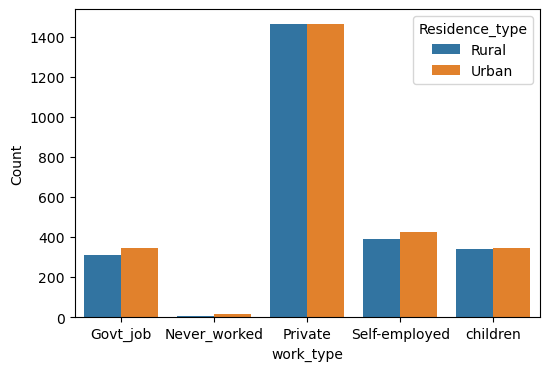

In [99]:
plt.figure(figsize=(6,4))
sns.barplot(data=grouped_data,x='work_type',y='Count',hue='Residence_type')
plt.show()

In [100]:
df.groupby(by=['heart_disease', 'stroke']).size().reset_index(name='count')

,heart_disease,stroke,count
0,0.0,0,4274
1,0.0,1,186
2,1.0,0,213
3,1.0,1,43


In [101]:
df.smoking_status.value_counts()

smoking_status
never smoked       1708
Unknown            1377
formerly smoked     802
smokes              712
Name: count, dtype: int64

In [102]:
len(df)

5110

In [103]:
label_encoder=LabelEncoder()
df['gender']=label_encoder.fit_transform(df['gender'])

In [104]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,NaN,NaN,Yes,Private,Urban,228.69,36.6,NaN,1
1,0,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,1,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,0,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,0,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [105]:
df.isnull().sum()

gender                 0
age                    0
hypertension         730
heart_disease        394
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status       511
stroke                 0
dtype: int64

In [106]:
df['ever_married']=label_encoder.fit_transform(df['ever_married'])

In [107]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,NaN,NaN,1,Private,Urban,228.69,36.6,NaN,1
1,0,61.0,0.0,0.0,1,Self-employed,Rural,202.21,NaN,never smoked,1
2,1,80.0,0.0,1.0,1,Private,Rural,105.92,32.5,never smoked,1
3,0,49.0,0.0,0.0,1,Private,Urban,171.23,34.4,smokes,1
4,0,79.0,1.0,0.0,1,Self-employed,Rural,174.12,24.0,never smoked,1


In [108]:
df['work_type'].value_counts()

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [109]:
df['work_type']=label_encoder.fit_transform(df['work_type'])

In [110]:
df['Residence_type']=label_encoder.fit_transform(df['Residence_type'])

In [111]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,NaN,NaN,1,2,1,228.69,36.6,NaN,1
1,0,61.0,0.0,0.0,1,3,0,202.21,NaN,never smoked,1
2,1,80.0,0.0,1.0,1,2,0,105.92,32.5,never smoked,1
3,0,49.0,0.0,0.0,1,2,1,171.23,34.4,smokes,1
4,0,79.0,1.0,0.0,1,3,0,174.12,24.0,never smoked,1


In [112]:
label_encoder.classes_

array(['Rural', 'Urban'], dtype=object)

In [113]:
df.loc[df['smoking_status']==4,'smoking_status']=np.nan

In [114]:
df.sample()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
307,1,51.0,0.0,0.0,1,0,1,220.49,43.1,Unknown,0


In [115]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,NaN,NaN,1,2,1,228.69,36.6,NaN,1
1,0,61.0,0.0,0.0,1,3,0,202.21,NaN,never smoked,1
2,1,80.0,0.0,1.0,1,2,0,105.92,32.5,never smoked,1
3,0,49.0,0.0,0.0,1,2,1,171.23,34.4,smokes,1
4,0,79.0,1.0,0.0,1,3,0,174.12,24.0,never smoked,1


In [116]:
df.isnull().sum()

gender                 0
age                    0
hypertension         730
heart_disease        394
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status       511
stroke                 0
dtype: int64

<Axes: >

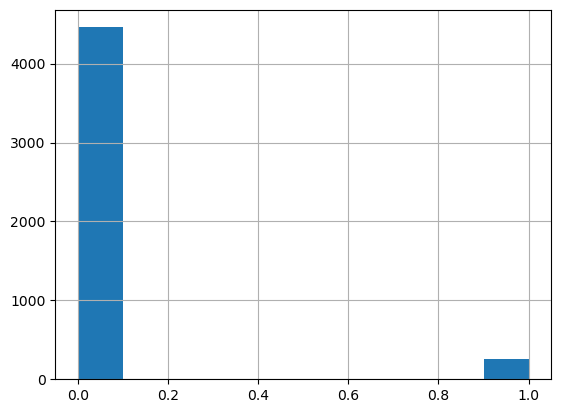

In [117]:
df['heart_disease'].hist()

<Axes: >

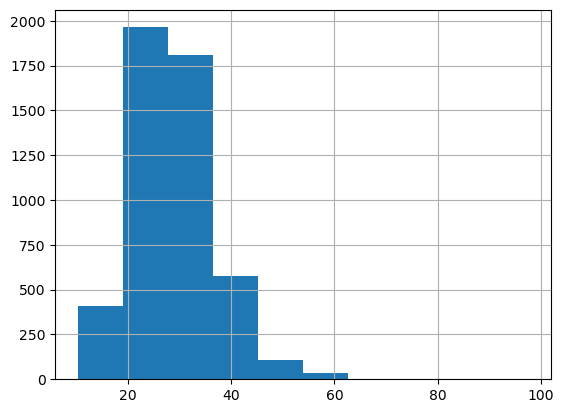

In [118]:
df['bmi'].hist()

In [119]:
median_imputer = SimpleImputer(strategy="median")

In [120]:
df[['bmi']]=median_imputer.fit_transform(df[['bmi']])

In [121]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,NaN,NaN,1,2,1,228.69,36.6,NaN,1
1,0,61.0,0.0,0.0,1,3,0,202.21,28.1,never smoked,1
2,1,80.0,0.0,1.0,1,2,0,105.92,32.5,never smoked,1
3,0,49.0,0.0,0.0,1,2,1,171.23,34.4,smokes,1
4,0,79.0,1.0,0.0,1,3,0,174.12,24.0,never smoked,1


In [122]:
df.isnull().sum()

gender                 0
age                    0
hypertension         730
heart_disease        394
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                    0
smoking_status       511
stroke                 0
dtype: int64

<Axes: >

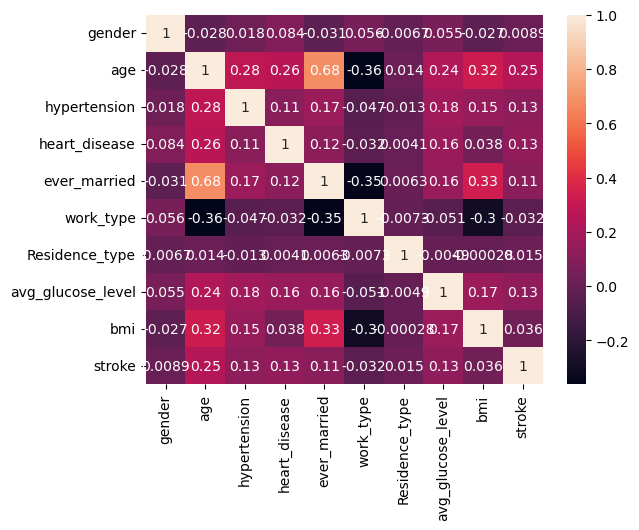

In [123]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: >

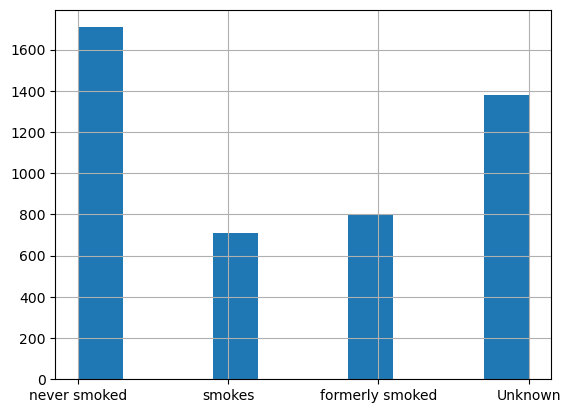

In [124]:
df['smoking_status'].hist()

In [125]:
dummies=pd.get_dummies(df['smoking_status'])
df=pd.concat([df,dummies],axis=1)
df.drop(columns=['smoking_status'],inplace=True)

In [126]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke,Unknown,formerly smoked,never smoked,smokes
0,1,67.0,NaN,NaN,1,2,1,228.69,36.6,1,False,False,False,False
1,0,61.0,0.0,0.0,1,3,0,202.21,28.1,1,False,False,True,False
2,1,80.0,0.0,1.0,1,2,0,105.92,32.5,1,False,False,True,False
3,0,49.0,0.0,0.0,1,2,1,171.23,34.4,1,False,False,False,True
4,0,79.0,1.0,0.0,1,3,0,174.12,24.0,1,False,False,True,False


<Axes: >

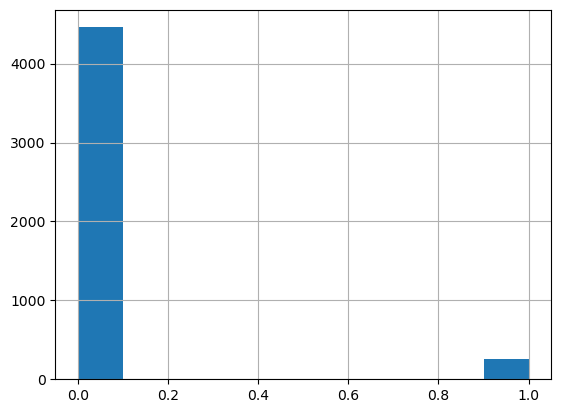

In [127]:
df['heart_disease'].hist()

In [128]:
knn_imputer = KNNImputer(n_neighbors=21)
df['heart_disease'] = knn_imputer.fit_transform(df[['heart_disease']])

In [129]:
df.isnull().sum()

gender                 0
age                    0
hypertension         730
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                    0
stroke                 0
Unknown                0
formerly smoked        0
never smoked           0
smokes                 0
dtype: int64

<Axes: >

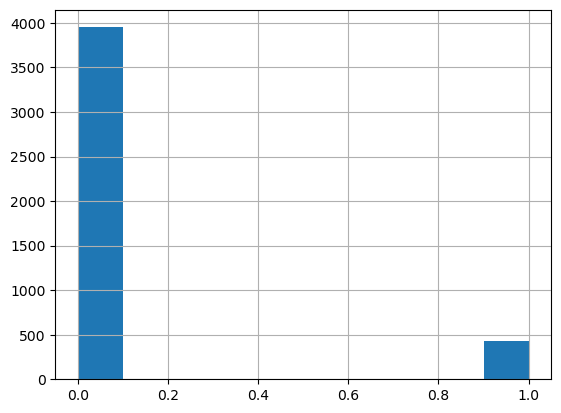

In [130]:
df['hypertension'].hist()

In [131]:
knn_imputer = KNNImputer(n_neighbors=31)
df['hypertension'] = knn_imputer.fit_transform(df[['hypertension']])

In [132]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
stroke               0
Unknown              0
formerly smoked      0
never smoked         0
smokes               0
dtype: int64

In [133]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke,Unknown,formerly smoked,never smoked,smokes
0,1,67.0,0.097945,0.054283,1,2,1,228.69,36.6,1,False,False,False,False
1,0,61.0,0.000000,0.000000,1,3,0,202.21,28.1,1,False,False,True,False
2,1,80.0,0.000000,1.000000,1,2,0,105.92,32.5,1,False,False,True,False
3,0,49.0,0.000000,0.000000,1,2,1,171.23,34.4,1,False,False,False,True
4,0,79.0,1.000000,0.000000,1,3,0,174.12,24.0,1,False,False,True,False


In [134]:
X=df.drop(columns=['stroke'])
y=df['stroke']

In [135]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

In [136]:
classifier = LogisticRegression().fit(train_X, train_y)

C:\Users\dimit\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   int64  
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   float64
 3   heart_disease      5110 non-null   float64
 4   ever_married       5110 non-null   int64  
 5   work_type          5110 non-null   int64  
 6   Residence_type     5110 non-null   int64  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   stroke             5110 non-null   int64  
 10  Unknown            5110 non-null   bool   
 11  formerly smoked    5110 non-null   bool   
 12  never smoked       5110 non-null   bool   
 13  smokes             5110 non-null   bool   
dtypes: bool(4), float64(5), int64(5)
memory usage: 419.3 KB


In [138]:
pred_y = classifier.predict(test_X)

In [139]:
print("Accuracy:",metrics.accuracy_score(test_y, pred_y))
print(confusion_matrix(test_y, pred_y))
print(classification_report(test_y, pred_y))

Accuracy: 0.9500978473581213
[[970   0]
 [ 51   1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       970
           1       1.00      0.02      0.04        52

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



In [140]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [143]:
data_stroke=df.loc[df['stroke']==1]

In [144]:
data_no_stroke=df.loc[df['stroke']==0]
data_no_stroke=data_no_stroke.sample(300)

In [145]:
new_data=pd.concat([data_stroke,data_no_stroke]).sample(frac=1)

In [146]:
X = new_data.drop(columns=['stroke'])
y = new_data['stroke']

In [147]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)
classifier = LogisticRegression().fit(train_X, train_y)
pred_y = classifier.predict(test_X)

print("Accuracy:",metrics.accuracy_score(test_y, pred_y))
print(confusion_matrix(test_y, pred_y))
print(classification_report(test_y, pred_y))

Accuracy: 0.7454545454545455
[[44 16]
 [12 38]]
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        60
           1       0.70      0.76      0.73        50

    accuracy                           0.75       110
   macro avg       0.74      0.75      0.74       110
weighted avg       0.75      0.75      0.75       110



C:\Users\dimit\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [148]:
model = XGBClassifier(max_depth=7, min_child_weight=1, n_estimators=50, n_jobs=-1, learning_rate=0.01)
model.fit(train_X, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=-1, num_parallel_tree=None, ...)

In [149]:
y_pred = model.predict(test_X)

print("Accuracy:",metrics.accuracy_score(test_y, y_pred))
print(confusion_matrix(test_y, y_pred))
print(classification_report(test_y, y_pred))

Accuracy: 0.7090909090909091
[[46 14]
 [18 32]]
              precision    recall  f1-score   support

           0       0.72      0.77      0.74        60
           1       0.70      0.64      0.67        50

    accuracy                           0.71       110
   macro avg       0.71      0.70      0.70       110
weighted avg       0.71      0.71      0.71       110

